# Obesity Risk Prediction

## Objective

The goal of this project is to predict obesity levels based on demographic, lifestyle, and dietary attributes.

This notebook includes:
- Data understanding
- Data preprocessing
- Exploratory data analysis
- Model training and evaluation
- Model export for production use

In [52]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import joblib

In [53]:
#Estilo geral dos gráficos
plt.style.use('default')

#Configurações globais do Matplotlib
plt.rcParams.update({
    'figure.figsize': (10, 6),          #tamanho padrão das figuras
    'axes.titlesize': 16,               #tamanho do título
    'axes.labelsize': 13,               #tamanho dos rótulos dos eixos
    'axes.titleweight': 'bold',         #título em negrito
    'axes.labelweight': 'medium',
    'axes.edgecolor': '#333333',      #cor das bordas dos eixos
    'axes.grid': True,                  #ativa a grade
    'grid.alpha': 0.3,                  #transparência da grade
    'grid.color': '#aaaaaa',
    'lines.linewidth': 2,               #espessura das linhas
    'lines.markersize': 6,
    'font.size': 12,                    #tamanho padrão da fonte
    'font.family': 'sans-serif',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'legend.frameon': False,            #remove a caixa da legenda
    'figure.autolayout': True,          #ajusta automaticamente margens
    'figure.facecolor': 'white',        #cor de fundo do gráfico
    'axes.facecolor': '#f9f9f9',      #cor de fundo dos eixos
})

#Tema padrão do Seaborn (harmoniza com o Matplotlib)
sns.set_theme(
    style="whitegrid",
    palette="deep",                     
    font_scale=1.1
)

In [54]:
BASE_DIR = Path().resolve().parent

DATA_PATH = BASE_DIR / "data" / "Obesity.csv"
MODEL_PATH = BASE_DIR / "src" / "models" / "xgb_model.joblib"

df = pd.read_csv(DATA_PATH)
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



## Renaming Columns

In [55]:
column_name = {
    'Gender': 'gender',
    'Age': 'age',
    'Height': 'height',
    'Weight': 'weight',
    'family_history': 'family_history',
    'FAVC': 'high_calorie_food',
    'FCVC': 'vegetable_consumption',
    'NCP': 'main_meals_per_day',
    'CAEC': 'snacks_between_meals',
    'SMOKE': 'smokes',
    'CH2O': 'water_intake',
    'SCC': 'calorie_monitoring',
    'FAF': 'physical_activity',
    'TUE': 'screen_time',
    'CALC': 'alcohol_consumption',
    'MTRANS': 'transportation',
    'Obesity': 'obesity_level'
}

df = df.rename(columns=column_name).copy()
df.columns

Index(['gender', 'age', 'height', 'weight', 'family_history',
       'high_calorie_food', 'vegetable_consumption', 'main_meals_per_day',
       'snacks_between_meals', 'smokes', 'water_intake', 'calorie_monitoring',
       'physical_activity', 'screen_time', 'alcohol_consumption',
       'transportation', 'obesity_level'],
      dtype='object')

In [56]:
# Renomear colunas
df = df.rename(columns=column_name).copy()
df

,gender,age,height,weight,family_history,high_calorie_food,vegetable_consumption,main_meals_per_day,snacks_between_meals,smokes,water_intake,calorie_monitoring,physical_activity,screen_time,alcohol_consumption,transportation,obesity_level
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


## Data Overview

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   gender                 2111 non-null   object 
 1   age                    2111 non-null   float64
 2   height                 2111 non-null   float64
 3   weight                 2111 non-null   float64
 4   family_history         2111 non-null   object 
 5   high_calorie_food      2111 non-null   object 
 6   vegetable_consumption  2111 non-null   float64
 7   main_meals_per_day     2111 non-null   float64
 8   snacks_between_meals   2111 non-null   object 
 9   smokes                 2111 non-null   object 
 10  water_intake           2111 non-null   float64
 11  calorie_monitoring     2111 non-null   object 
 12  physical_activity      2111 non-null   float64
 13  screen_time            2111 non-null   float64
 14  alcohol_consumption    2111 non-null   object 
 15  tran

In [58]:
df.describe()

,age,height,weight,vegetable_consumption,main_meals_per_day,water_intake,physical_activity,screen_time
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [59]:
df.shape

(2111, 17)

## Data Cleaning

In [60]:
df.isnull().sum()

gender                   0
age                      0
height                   0
weight                   0
family_history           0
high_calorie_food        0
vegetable_consumption    0
main_meals_per_day       0
snacks_between_meals     0
smokes                   0
water_intake             0
calorie_monitoring       0
physical_activity        0
screen_time              0
alcohol_consumption      0
transportation           0
obesity_level            0
dtype: int64

In [61]:
df.duplicated().sum()

np.int64(24)

In [62]:
df = df.drop_duplicates()

print("Remaining duplicates:", df.duplicated().sum())

Remaining duplicates: 0


In [63]:
df.shape

(2087, 17)

Now we don't have any missing or duplicates values

## Encoding Categorical Variables

In [64]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

C:\Users\luish\AppData\Local\Temp\ipykernel_1828\4134231849.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col])
C:\Users\luish\AppData\Local\Temp\ipykernel_1828\4134231849.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col])
C:\Users\luish\AppData\Local\Temp\ipykernel_1828\4134231849.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

## Exploratory Data Analysis

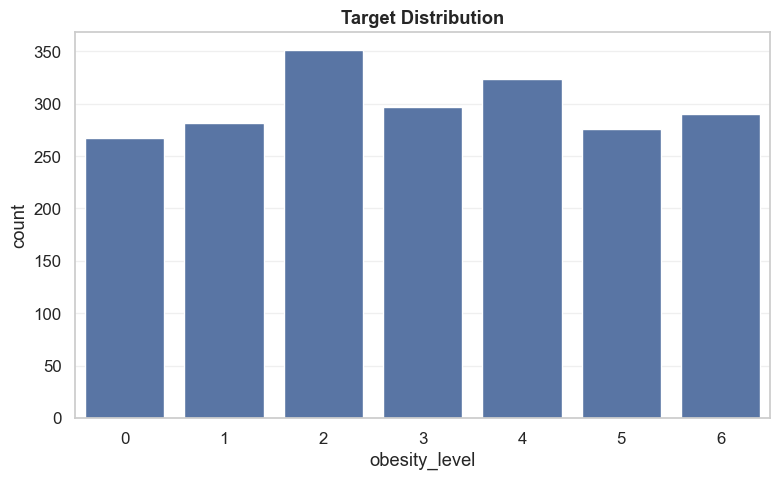

In [65]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='obesity_level')
plt.title('Target Distribution')
plt.show()

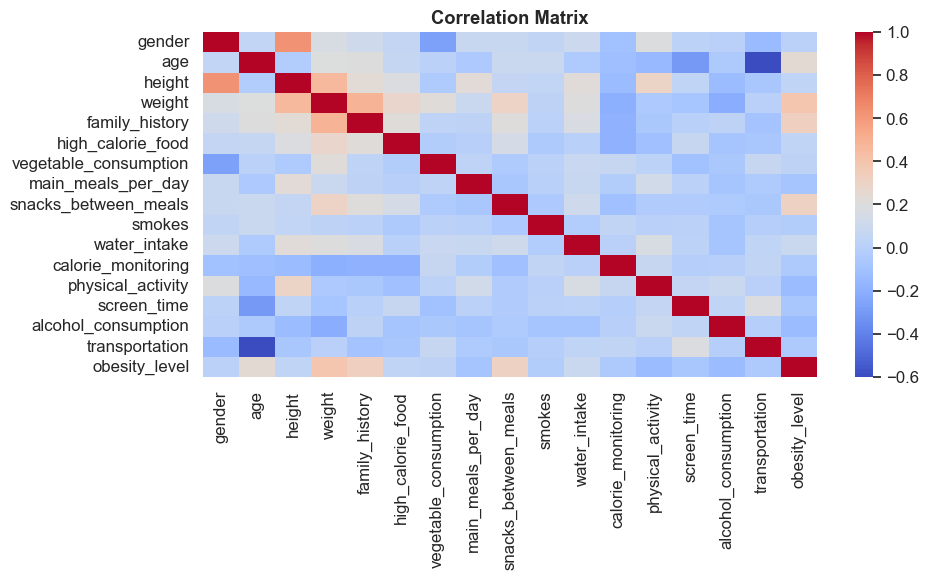

In [66]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

The dataset presents meaningful relationships between features and obesity levels.

## Train-Test Split

In [67]:
X = df.drop('obesity_level', axis=1)
y = df['obesity_level']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Training

In [68]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

xgb_model = XGBClassifier(eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


## Model Evaluation

In [69]:
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)

print("Random Forest Accuracy:", rf_acc)
print("XGBoost Accuracy:", xgb_acc)

Random Forest Accuracy: 0.9545454545454546
XGBoost Accuracy: 0.9665071770334929


In [70]:
print("Classification Report - XGBoost")
print(classification_report(y_test, xgb_pred))


Classification Report - XGBoost
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        59
           1       0.90      0.90      0.90        61
           2       1.00      0.99      0.99        70
           3       1.00      1.00      1.00        64
           4       1.00      1.00      1.00        60
           5       0.94      0.93      0.94        55
           6       0.96      1.00      0.98        49

    accuracy                           0.97       418
   macro avg       0.97      0.97      0.97       418
weighted avg       0.97      0.97      0.97       418



## Cross-Validation

To further validate the model's performance, a 5-fold cross-validation was applied using `cross_val_score`.

This technique splits the dataset into five different subsets (folds). The model is trained on four folds and tested on the remaining one. This process is repeated five times, ensuring that each subset is used once as a test set.

The final result is the average accuracy across all folds:

- **Cross-validation accuracy: ~0.955**

This result is very close to the test accuracy (~0.966), indicating that the model generalizes well and is not overfitting. It confirms that the model performs consistently across different subsets of the data.

In [71]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb_model, X, y, cv=5)
print("CV Accuracy:", scores.mean())

CV Accuracy: 0.9554863286404369


## Final Model Selection

In [72]:
best_model = xgb_model

In [73]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(best_model, MODEL_PATH)

print(f"Model saved at: {MODEL_PATH}")

Model saved at: C:\Users\luish\OneDrive\ARQUIVOS_NOTE\Área de Trabalho\obesity-prediction-app\src\models\xgb_model.joblib


## Model Inference Test

In [74]:
loaded_model = joblib.load(MODEL_PATH)

sample = X.iloc[[0]]
prediction = loaded_model.predict(sample)

print("Sample prediction:", prediction)

Sample prediction: [1]


In [75]:
def create_logo(path=None, hospital=None):
    if path is None:
        path = st.session_state.get("LOGO_PATH", "")
    if hospital is None:
        hospital = st.session_state.get("HOSPITAL_NAME", "")